# Create blood subset

In [1]:
here::i_am("revision/blood_trajectory/01_subset_cells.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [6]:
args <- list()
args$sce <-file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
args$metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$trajectory_name <- "blood"
args$celltype_label <- "celltype"
args$outdir <- file.path(io$basedir,"results/revisions/blood_trajectory/")
args$n_pcs <- 5
args$sample <- c('E7.5_rep1','E7.5_rep2','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')
 # ,'E7.75_rep1' removed!!
# I/O
dir.create(args$outdir, showWarnings=F, recursive=T)

In [3]:
# Options
opts$celltype_trajectory_dic <- list(
  "epiblast_blood" =  c("Epiblast",
                        "Primitive_Streak" ,
                        "Nascent_mesoderm",
                        "ExE_mesoderm",
                        "Mixed_mesoderm",
                        "Allantois",
                        "Mesenchyme",
                        "Haematoendothelial_progenitors",
                        "Endothelium",
                        "Blood_progenitors_1",
                        "Blood_progenitors_2",
                        "Erythroid1",
                        "Erythroid2",
                        "Erythroid3"),
  "blood" = c("Nascent_mesoderm",
              "Mixed_mesoderm",
              "Haematoendothelial_progenitors", 
              "Blood_progenitors_1", 
              "Blood_progenitors_2", 
              "Erythroid1", 
              "Erythroid2", 
              "Erythroid3"),
  "ectoderm" = c("Epiblast", "Rostral_neurectoderm", "Forebrain_Midbrain_Hindbrain"),
  "endoderm" = c("Epiblast", "Anterior_Primitive_Streak", "Def._endoderm", "Gut"),
  "mesoderm" = c("Epiblast", "Primitive_Streak", "Nascent_mesoderm"),
  "nmp" = c("NMP","Caudal_Mesoderm", "Somitic_mesoderm", "Spinal_cord")
  )

stopifnot(args$trajectory_name%in%names(opts$celltype_trajectory_dic))
opts$celltypes <- opts$celltype_trajectory_dic[[args$trajectory_name]]

opts$genes2plot <- list(
  "epiblast_blood" = c("Dnmt3b", "Mixl1", "Hbb-y","Etv2"),
  "blood" = c("Hbb-y","Eomes", "Gata2", "Gata1"),
  "ectoderm" = c("Utf1","Crabp1"),
  "endoderm" = c("Pou5f1","Krt8"),
  "mesoderm" = c("Dnmt3b","Mesp1"),
  "nmp" = c("Sox2","T")
)

stopifnot(args$trajectory_name%in%names(opts$genes2plot))
opts$genes_to_plot <- opts$genes2plot[[args$trajectory_name]]

In [4]:
#### ATAC metadata has cells that are not present in RNA....?
# Quick fix below
atac_metadata <- fread(file.path(io$basedir,"/results/atac/archR/qc/sample_metadata_after_qc.txt.gz")) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE & !sample %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]

rna_metadata <- fread(file.path(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & !sample %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]

sample_metadata = rna_metadata[match(atac_metadata$cell, cell)]
sample_metadata = sample_metadata[!is.na(sample_metadata$cell)] %>%
  .[,celltype:=eval(as.name(args$celltype_label))] %>%
  .[celltype%in%opts$celltypes] %>%
  .[,celltype:=factor(celltype,levels=opts$celltypes)] %>%
  .[sample%in% args$sample] %>%
  .[! (celltype == "Haematoendothelial_progenitors" & stage %in% c('E8.0', 'E8.5', 'E8.75'))]

table(sample_metadata$celltype, sample_metadata$stage)

# Save
fwrite(sample_metadata, file.path(args$outdir,sprintf("%s_sample_metadata.txt.gz",args$trajectory_name)), sep='\t')

                                
                                 E7.5 E8.0 E8.5 E8.75
  Nascent_mesoderm               1037    0    0     0
  Mixed_mesoderm                  239    0    3     0
  Haematoendothelial_progenitors  378    0    0     0
  Blood_progenitors_1             162   25   21    15
  Blood_progenitors_2             166  314   50    16
  Erythroid1                        0  415  533   165
  Erythroid2                        0   23  602   312
  Erythroid3                        0    0  141    46

In [5]:
#########################
## Load RNA expression ##
#########################
  
sce <- load_SingleCellExperiment(
  file = args$sce, 
  normalise = TRUE, 
  cells = sample_metadata$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- sample_metadata %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

In [7]:
# RNA dimreduction

decomp <- modelGeneVar(sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=2500) %>% rownames

sce_filt <- sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = args$n_pcs, ntop=2500)

In [8]:
#########
## PCA ##
#########
options(repr.plot.width=8, repr.plot.height=5)

# maybe need to incorporate batch control still.
# Or run metacells per stage and then compare GRNs of the different haematoendo stages/waves.
sce_filt <- runPCA(sce_filt, ncomponents = args$n_pcs, ntop=nrow(sce_filt))

# save
fwrite(as.data.table(reducedDim(sce_filt,"PCA"), keep.rownames=T) %>% setnames('rn', 'cell'), 
                     file.path(args$outdir,sprintf("PCA_%s.csv",args$n_pcs)))

# Define the starting point
foo <- mean(reducedDim(sce_filt,"PCA")[sce_filt$celltype==opts$celltypes[1],"PC1"])
if (foo>0) reducedDim(sce_filt,"PCA")[,"PC1"] <- -reducedDim(sce_filt,"PCA")[,"PC1"]


# Plot PCA
pdf(file.path(args$outdir,sprintf("%s_pca_celltype.pdf",args$trajectory_name)), width=8, height=5)
plotPCA(sce_filt, colour_by="celltype", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$celltype.colors) + theme(legend.position="none")
dev.off()

pdf(file.path(args$outdir,sprintf("%s_pca_stage.pdf",args$trajectory_name)), width=8, height=5)
plotPCA(sce_filt, colour_by="stage", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$stage.colors) + theme(legend.position="top", legend.title = element_blank())
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


png 
  2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


png 
  2

In [9]:
###################
## Diffusion map ##
###################

set.seed(42)
dm <- DiffusionMap(sce_filt, n_pcs=args$n_pcs)

# Add to the SingleCellExperiment object
reducedDim(sce_filt, "DiffusionMap") <- dm@eigenvectors[,c(1,2)]

# Define the starting point
foo <- mean(reducedDim(sce_filt,"DiffusionMap")[sce_filt$celltype==opts$celltypes[1],"DC1"])
if (foo>0) reducedDim(sce_filt,"DiffusionMap")[,"DC1"] <- -reducedDim(sce_filt,"DiffusionMap")[,"DC1"]

# Plot
pdf(file.path(args$outdir,sprintf("%s_diffmap_celltype.pdf",args$trajectory_name)), width=8, height=5)
plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="celltype", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$celltype.colors) + theme(legend.position="none")
dev.off()

pdf(file.path(args$outdir,sprintf("%s_diffmap_stage.pdf",args$trajectory_name)), width=8, height=5)
plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="stage", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$stage.colors) + theme(legend.position="top", legend.title = element_blank())
dev.off()

Warning message:
“as(<dsCMatrix>, "dsTMatrix") is deprecated since Matrix 1.5-0; do as(., "TsparseMatrix") instead”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


png 
  2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


png 
  2

In [11]:
####################
## Prepare output ##
####################

pseudotime.dt <- data.table(
  cell = colnames(sce_filt),
  PC1 = reducedDim(sce_filt,"PCA")[,"PC1"],
  DC1 = reducedDim(sce_filt,"DiffusionMap")[,"DC1"],
  DC2 = reducedDim(sce_filt,"DiffusionMap")[,"DC2"]

) %>% setorder(PC1)

# Save
fwrite(pseudotime.dt, file.path(args$outdir,sprintf("/%s_trajectory.txt.gz",args$trajectory_name)))

################################################
## Boxplots of pseudotime values per celltype ##
################################################

to.plot <- pseudotime.dt %>%
  merge(sample_metadata[,c("cell","celltype","stage")], by="cell") %>%
  .[,pca:=minmax.normalisation(PC1)] %>% .[,diffmap:=minmax.normalisation(DC1)]

for (i in c("pca","diffmap")) {
  p <- ggboxplot(to.plot, x="celltype", y=i, fill="celltype", outlier.shape=NA) +
    scale_fill_manual(values=opts$celltype.colors[opts$celltypes]) +
    stat_summary(fun.data = give.n, geom = "text", size=4) +
    labs(x="", y=sprintf("Pseudotime (%s)",i)) +
    theme_classic() +
    theme(
      legend.position = "none",
      # legend.position = c(.8,.3),
      legend.title = element_blank(),
      axis.text.x = element_text(angle=-25, hjust=0, vjust=1),
      axis.ticks.x = element_blank(),
      # axis.text.x = element_text(color="black", size=rel(0.75)),
      axis.text.y = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_text(color="black", size=rel(1)),
      axis.title.x = element_blank()
    )
  
  pdf(file.path(args$outdir,sprintf("%s_%s_boxplot_celltype.pdf",args$trajectory_name,i)), width=6, height=3.5)
  print(p)
  dev.off()
}

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation ideoms with `aes()`”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


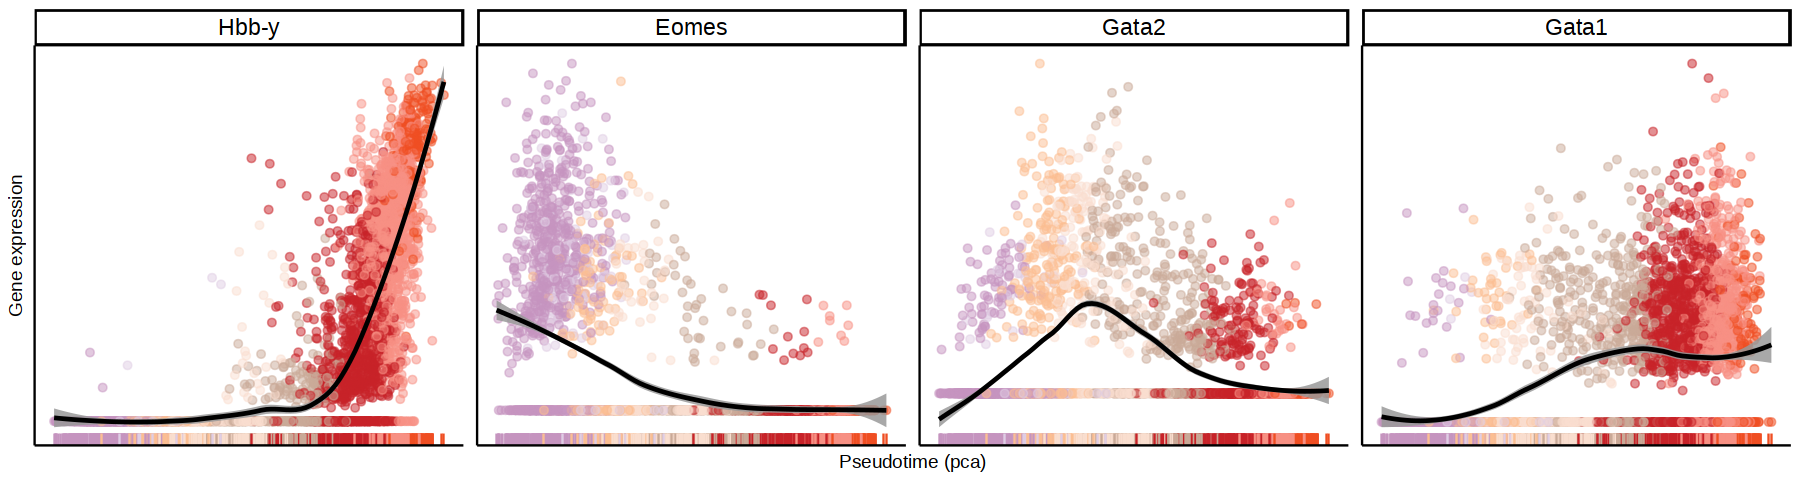

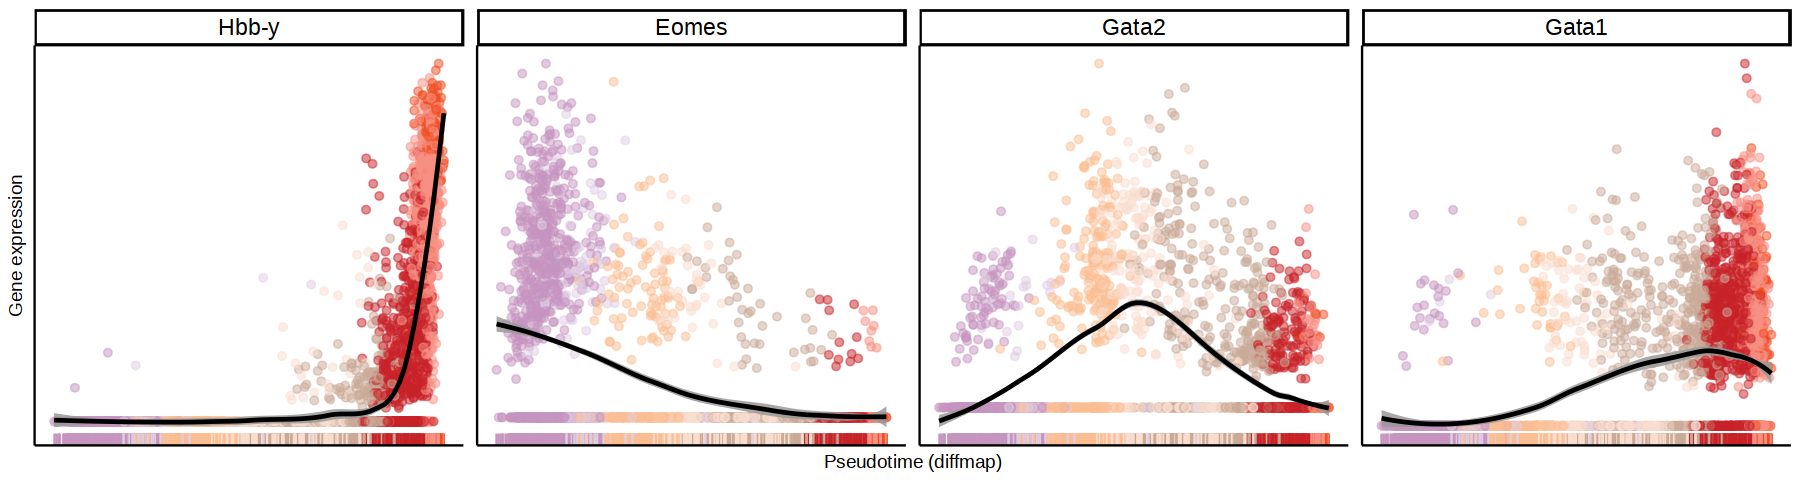

In [12]:
#########################################################################
## Scatterplots of pseudotime values versus expression of marker genes ##
#########################################################################

# Denoise
# pca.rna <- fread(io$pca.rna) %>% matrix.please %>% .[colnames(sce),]
# assay(sce_filt,"logcounts_denoised") <- smoother_aggregate_nearest_nb(mat=as.matrix(logcounts(sce_filt)), D=pdist(pca.rna), k=25)

rna.dt <- data.table(as.matrix(logcounts(sce)[opts$genes_to_plot,]), keep.rownames = T) %>% 
  setnames("rn","gene") %>%
  melt(id.vars="gene", variable.name="cell", value.name="expr") %>% 
  merge(sample_metadata[,c("cell","celltype","stage")])

to.plot2 <- to.plot %>% 
  merge(rna.dt[gene%in%opts$genes_to_plot],by=c("cell", "celltype", "stage")) %>%
  .[,gene:=factor(gene,levels=opts$genes_to_plot)] %>%
  .[,expr:=minmax.normalisation(expr),by="gene"]

for (i in c("pca","diffmap")) {
    p <- ggplot(to.plot2, aes_string(x=i, y="expr")) +
        geom_point(aes(col=celltype), size=1.75, alpha=0.5) +
        stat_smooth(method="loess", color="black", alpha=0.85, span=0.5) +
        geom_rug(aes(color=celltype), sides="b") +
        scale_color_manual(values=opts$celltype.colors) +
        #    scale_fill_manual(values=opts$celltype.colors) +
        facet_wrap(~gene, scales="free_y", nrow=1) +
        labs(x=sprintf("Pseudotime (%s)",i), y="Gene expression") +
        theme_classic() +
        guides(fill="none", color="none") +
        theme(
          axis.text.x = element_blank(),
          axis.text.y = element_blank(),
          # axis.text.y = element_text(color="black"),
          axis.ticks.x = element_blank(),
          axis.ticks.y = element_blank(),
          strip.text = element_text(size=rel(1.25), color="black"),
          legend.position="right",
          legend.title = element_blank()
        )

    pdf(file.path(args$outdir,sprintf("%s_%s_vs_expression.pdf",args$trajectory_name,i)), width=7.5, height=4)
        print(p)
    dev.off()
    options(repr.plot.width=15, repr.plot.height=4)
    print(p)
}

In [ ]:
#########################################################################
## Scatterplots of pseudotime values versus expression of marker genes ##
#########################################################################

# Denoise
pca.rna <- fread(file.path(args$outdir,sprintf("PCA_%s.csv",args$n_pcs))) %>% matrix.please %>% .[colnames(sce),]
assay(sce_filt,"logcounts_denoised") <- smoother_aggregate_nearest_nb(mat=as.matrix(logcounts(sce_filt)), D=pdist(pca.rna), k=25)

rna.dt <- data.table(as.matrix(assay(sce_filt,"logcounts_denoised")[opts$genes_to_plot,]), keep.rownames = T) %>% 
  setnames("rn","gene") %>%
  melt(id.vars="gene", variable.name="cell", value.name="expr") %>% 
  merge(sample_metadata[,c("cell","celltype","stage")])

to.plot2 <- to.plot %>% 
  merge(rna.dt[gene%in%opts$genes_to_plot],by=c("cell", "celltype", "stage")) %>%
  .[,gene:=factor(gene,levels=opts$genes_to_plot)] %>%
  .[,expr:=minmax.normalisation(expr),by="gene"]

for (i in c("pca","diffmap")) {
    p <- ggplot(to.plot2, aes_string(x=i, y="expr")) +
        geom_point(aes(col=celltype), size=1.75, alpha=0.5) +
        stat_smooth(method="loess", color="black", alpha=0.85, span=0.5) +
        geom_rug(aes(color=celltype), sides="b") +
        scale_color_manual(values=opts$celltype.colors) +
        #    scale_fill_manual(values=opts$celltype.colors) +
        facet_wrap(~gene, scales="free_y", nrow=1) +
        labs(x=sprintf("Pseudotime (%s)",i), y="Gene expression") +
        theme_classic() +
        guides(fill="none", color="none") +
        theme(
          axis.text.x = element_blank(),
          axis.text.y = element_blank(),
          # axis.text.y = element_text(color="black"),
          axis.ticks.x = element_blank(),
          axis.ticks.y = element_blank(),
          strip.text = element_text(size=rel(1.25), color="black"),
          legend.position="right",
          legend.title = element_blank()
        )

    pdf(file.path(args$outdir,sprintf("%s_%s_vs_expression.pdf",args$trajectory_name,i)), width=7.5, height=4)
        print(p)
    dev.off()
    options(repr.plot.width=15, repr.plot.height=4)
    print(p)
}